# 04 — Хорды ЛЖ, VO₂max, гемодинамическая нагрузка и wall stress

**Цель ноутбука:** посмотреть, как фенотип ложных хорд ЛЖ связан с:

1. функциональной работоспособностью / `VO2max`;
2. гемодинамической нагрузкой давлением: `hemo_sbp_rest_mmhg`, `hemo_sbp_exercise_mmhg`, `dsws`;
3. расчётной механической нагрузкой на стенку ЛЖ: `echo_lv_sws_rest_g_cm2`, `echo_lv_sws_max_g_cm2`, `echo_lv_sws_delta_g_cm2`;
4. механикой ЛЖ: strain, strain rate, DICOR, геометрия.

## Главная логика

Мы не проверяем «всё со всем». Мы строим иерархию анализа:

```text
Хорды / фенотип хорд
        ↓
VO2max / функциональная работоспособность
        ↓
САД и прирост САД на нагрузке
        ↓
SWS / напряжение стенки ЛЖ
        ↓
региональная механика / strain / strain rate / DICOR / геометрия
```

При этом `dsws` и `echo_lv_sws_delta_g_cm2` — разные слои:

```text
dsws                    = прирост САД, мм рт. ст.
echo_lv_sws_delta_g_cm2 = прирост напряжения стенки ЛЖ, г/см²
```

## 0. Иерархия статистических инструментов

| Уровень | Вопрос | Инструменты | Что считаем главным |
|---:|---|---|---|
| 0 | Данные готовы? | audit, missingness, ranges, n per variable | можно ли вообще моделировать |
| 1 | Как выглядят переменные? | describe, histogram, boxplot + stripplot | форма распределения, выбросы, группы |
| 2 | Есть ли простые связи? | Spearman, Kendall, scatter/regplot, FDR | направление и размер связи, не только p-value |
| 3 | Различаются ли группы хорд? | Mann–Whitney / Kruskal–Wallis, Hedges g, bootstrap CI | размер эффекта и устойчивость |
| 4 | Сохраняется ли связь после поправок? | OLS / robust HC3, иерархические модели | ΔR², AIC, коэффициенты, CI |
| 5 | Есть ли механизм? | mediation-style logic, interactions | VO2max/SWS как медиатор или модератор |
| 6 | Насколько результат устойчив? | bootstrap, leave-one-out, sensitivity without outliers | стабильность знака и величины эффекта |
| 7 | Много признаков хорд | Elastic Net / sparse PLS только exploratory | не доказательство, а генерация гипотез |

**Правило:** более сложный метод используем только если предыдущий уровень дал осмысленный сигнал и хватает `n`.

In [1]:
# 1. Imports
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd

from scipy import stats
from statsmodels.stats.multitest import multipletests
import statsmodels.formula.api as smf

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Publication-like style
sns.set_theme(style="white", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,
    "axes.edgecolor": "black",
    "axes.linewidth": 1.0,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "font.family": "DejaVu Sans",
})

In [2]:
# 2. Paths and run metadata
# Проверь путь перед запуском. Если работаешь из корня проекта, можно заменить на Path.cwd() / "data" / "..."
PROJECT_ROOT = Path(r"C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords")
DATA_PATH = PROJECT_ROOT / "data" / "final_analysis_dataset_ver2.xlsx"

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "chords_vo2max_sws"
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
DIAG_DIR = OUTPUT_DIR / "diagnostics"

for p in [OUTPUT_DIR, FIG_DIR, TABLE_DIR, DIAG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

DATASET_VERSION = "final_analysis_dataset_ver2_plus_hemo_sws"
NOTEBOOK_NAME = "04_chords_vo2max_sws_hierarchy.ipynb"

run_manifest = {
    "dataset_version": DATASET_VERSION,
    "dataset_file": str(DATA_PATH),
    "notebook": NOTEBOOK_NAME,
    "random_seed": RANDOM_STATE,
    "analysis_goal": "Relationships among false LV chord phenotype, VO2max, SBP response, LV wall stress, and myocardial mechanics",
}

run_manifest

{'dataset_version': 'final_analysis_dataset_ver2_plus_hemo_sws',
 'dataset_file': 'C:\\Users\\Ars\\projects\\university\\lab_urfu_2026\\false-lv-chords\\data\\final_analysis_dataset_ver2.xlsx',
 'notebook': '04_chords_vo2max_sws_hierarchy.ipynb',
 'random_seed': 42,
 'analysis_goal': 'Relationships among false LV chord phenotype, VO2max, SBP response, LV wall stress, and myocardial mechanics'}

In [3]:
# 3. Variable registry
# Важно: списки не переименовывают колонки в датасете. Они только помогают искать нужные переменные.

NEW_PRESSURE_VARS = [
    "hemo_sbp_rest_mmhg",
    "hemo_sbp_exercise_mmhg",
    "dsws",
]

SWS_VARS = [
    "echo_lv_sws_rest_g_cm2",
    "echo_lv_sws_max_g_cm2",
    "echo_lv_sws_delta_g_cm2",
]

# Возможные названия VO2max. Код ниже сам выберет то, что реально есть в датасете.
VO2MAX_CANDIDATES = [
    "vo2max",
    "vo2_max",
    "VO2max",
    "VO2 max",
    "VO2MAX",
    "exercise_vo2max_ml_kg_min",
    "exercise_vo2_max_ml_kg_min",
    "vo2max_ml_kg_min",
    "vo2_max_ml_kg_min",
    "relative_vo2max_ml_kg_min",
    "cardio_vo2max_ml_kg_min",
]

# Основные признаки хорд / фенотипа хорд.
# Если части переменных нет — notebook просто пропустит их.
CHORD_CORE_VARS = [
    "lv_false_tendon_total_count",
    "significant_lv_chord_bp_count",
    "Chord_Topology_Class",
    "Chord_Spread_Class",
    "Chord_Orientation",
    "chord_type_complexity_class",
    "chord_spread_class",
    "chord_orientation",
    "chord_topology_class",
]

# Возможные исходы механики и геометрии.
OUTCOME_VARS = [
    "echo_lv_strain_plus_cv_pct",
    "echo_lv_strain_rate_cv_pct",
    "dicor_ssou_cv_pct",
    "dicor_sm_kdtr_cv_pct",
    "echo_lv_sphericity_index_end_diastolic_ratio",
    "echo_lv_sphericity_index_end_systolic_ratio",
    "echo_lv_ejection_fraction_simpson_pct",
    "echo_lv_ejection_fraction_teichholz_pct",
]

BASE_COVARIATES = [
    "age_years",
    "sex",
    "body_surface_area_m2",
    "body_mass_index_kg_m2",
]

# Будем отдельно искать сегментные attachment-флаги, если понадобится топологический слой.
ATTACHMENT_PATTERN = "chord_attachment"

In [4]:
# 4. Helper functions

def read_dataset(path: Path) -> pd.DataFrame:
    """Read xlsx/csv/parquet without changing column names."""
    if not path.exists():
        raise FileNotFoundError(f"Dataset not found: {path}")
    if path.suffix.lower() in [".xlsx", ".xls"]:
        return pd.read_excel(path)
    if path.suffix.lower() == ".csv":
        return pd.read_csv(path)
    if path.suffix.lower() == ".parquet":
        return pd.read_parquet(path)
    raise ValueError(f"Unsupported file type: {path.suffix}")


def existing(cols, df):
    """Return variables that exist in df."""
    return [c for c in cols if c in df.columns]


def missing(cols, df):
    """Return variables that do not exist in df."""
    return [c for c in cols if c not in df.columns]


def find_by_substring(df, substrings):
    if isinstance(substrings, str):
        substrings = [substrings]
    out = []
    for c in df.columns:
        low = str(c).lower()
        if any(s.lower() in low for s in substrings):
            out.append(c)
    return out


def coerce_numeric_safe(s: pd.Series) -> pd.Series:
    """Convert Russian decimal comma and text numbers to numeric where possible."""
    if pd.api.types.is_numeric_dtype(s):
        return s
    return pd.to_numeric(
        s.astype(str)
         .str.replace(",", ".", regex=False)
         .str.replace(" ", "", regex=False)
         .replace({"nan": np.nan, "None": np.nan, "": np.nan, "-": np.nan, ".": np.nan}),
        errors="coerce",
    )


def var_audit(df, variables):
    rows = []
    for v in variables:
        if v in df.columns:
            s = df[v]
            rows.append({
                "variable": v,
                "exists": True,
                "dtype": str(s.dtype),
                "n_non_missing": int(s.notna().sum()),
                "n_missing": int(s.isna().sum()),
                "missing_pct": round(float(s.isna().mean() * 100), 2),
                "n_unique": int(s.nunique(dropna=True)),
            })
        else:
            rows.append({
                "variable": v,
                "exists": False,
                "dtype": None,
                "n_non_missing": 0,
                "n_missing": None,
                "missing_pct": None,
                "n_unique": None,
            })
    return pd.DataFrame(rows)


def save_table(df, name):
    path = TABLE_DIR / name
    df.to_excel(path, index=False)
    print(f"Saved: {path}")
    return path

In [5]:
# 5. Load data
# Если появится ошибка FileNotFoundError — сначала проверь DATA_PATH в ячейке 2.
df = read_dataset(DATA_PATH)

print("Shape:", df.shape)
print("Columns sample:")
df.columns[:30].tolist()

Shape: (153, 222)
Columns sample:


['subject_full_name',
 'age',
 'height_cm',
 'weight_cm',
 'BSA',
 'sex',
 'IMT',
 'echo_ascending_aorta_diameter_mm_div_bsa',
 'echo_ascending_aorta_diameter_mm',
 'echo_aortic_sinus_diameter_mm_div_bsa',
 'echo_aortic_sinus_diameter_mm',
 'echo_aortic_valve_annulus_diameter_mm',
 'echo_aortic_cusp_separation_mm',
 'Е/А',
 'echo_lv_end_diastolic_volume_index_ml_m2',
 'echo_lv_end_diastolic_volume_teichholz_ml',
 'echo_lv_end_systolic_volume_index_ml_m2',
 'echo_lv_end_systolic_volume_teichholz_ml',
 'echo_lv_ejection_fraction_teichholz_pct',
 'echo_lv_stroke_volume_teichholz_ml',
 'echo_lv_end_diastolic_volume_index_simpson_ml_m2',
 'echo_lv_end_diastolic_volume_simpson_ml',
 'echo_lv_end_systolic_volume_index_simpson_ml_m2',
 'echo_lv_end_systolic_volume_simpson_ml',
 'echo_lv_ejection_fraction_simpson_pct',
 'echo_lv_stroke_volume_simpson_ml',
 'echo_lv_end_diastolic_diameter_mm',
 'echo_lv_end_systolic_diameter_mm',
 'echo_lv_myocardial_mass_index_g_m2',
 'echo_lv_relative_wall_thi

In [6]:
# 6. Find VO2max and chord attachment columns
vo2_existing = existing(VO2MAX_CANDIDATES, df)
vo2_by_search = find_by_substring(df, ["vo2", "vo₂", "мпк", "пмк"])

VO2MAX_VAR = vo2_existing[0] if vo2_existing else (vo2_by_search[0] if vo2_by_search else None)
ATTACHMENT_VARS = find_by_substring(df, ATTACHMENT_PATTERN)

print("VO2MAX_VAR:", VO2MAX_VAR)
print("VO2 candidates found:", vo2_by_search)
print("Attachment vars found:", len(ATTACHMENT_VARS))
ATTACHMENT_VARS[:10]

VO2MAX_VAR: vo2_max_absolute_ml_min
VO2 candidates found: ['vo2_max_absolute_ml_min']
Attachment vars found: 18


['strain_plus_basal_anteroseptal_chord_attachment_flag',
 'strain_plus_basal_anterior_chord_attachment_flag',
 'strain_plus_basal_anterolateral_chord_attachment_flag',
 'strain_plus_basal_inferolateral_chord_attachment_flag',
 'strain_plus_basal_inferior_chord_attachment_flag',
 'strain_plus_basal_inferoseptal_chord_attachment_flag',
 'strain_plus_mid_anteroseptal_chord_attachment_flag',
 'strain_plus_mid_anterior_chord_attachment_flag',
 'strain_plus_mid_anterolateral_chord_attachment_flag',
 'strain_plus_mid_inferolateral_chord_attachment_flag']

In [7]:
# 7. Derived variable checks
# Ничего не пересчитываем насильно, но если delta отсутствует, а компоненты есть — создаём.
# Если delta уже есть, проверяем расхождение с расчётом.

df_work = df.copy()

if "dsws" not in df_work.columns and {"hemo_sbp_exercise_mmhg", "hemo_sbp_rest_mmhg"}.issubset(df_work.columns):
    df_work["dsws"] = coerce_numeric_safe(df_work["hemo_sbp_exercise_mmhg"]) - coerce_numeric_safe(df_work["hemo_sbp_rest_mmhg"])
    print("Created dsws = hemo_sbp_exercise_mmhg - hemo_sbp_rest_mmhg")

if "echo_lv_sws_delta_g_cm2" not in df_work.columns and {"echo_lv_sws_max_g_cm2", "echo_lv_sws_rest_g_cm2"}.issubset(df_work.columns):
    df_work["echo_lv_sws_delta_g_cm2"] = coerce_numeric_safe(df_work["echo_lv_sws_max_g_cm2"]) - coerce_numeric_safe(df_work["echo_lv_sws_rest_g_cm2"])
    print("Created echo_lv_sws_delta_g_cm2 = echo_lv_sws_max_g_cm2 - echo_lv_sws_rest_g_cm2")

# Проверка согласованности delta-переменных
checks = []
if {"dsws", "hemo_sbp_exercise_mmhg", "hemo_sbp_rest_mmhg"}.issubset(df_work.columns):
    calc = coerce_numeric_safe(df_work["hemo_sbp_exercise_mmhg"]) - coerce_numeric_safe(df_work["hemo_sbp_rest_mmhg"])
    diff = coerce_numeric_safe(df_work["dsws"]) - calc
    checks.append({
        "variable": "dsws",
        "mean_abs_diff_vs_recalc": float(diff.abs().mean(skipna=True)),
        "max_abs_diff_vs_recalc": float(diff.abs().max(skipna=True)),
        "n_checked": int(diff.notna().sum()),
    })

if {"echo_lv_sws_delta_g_cm2", "echo_lv_sws_max_g_cm2", "echo_lv_sws_rest_g_cm2"}.issubset(df_work.columns):
    calc = coerce_numeric_safe(df_work["echo_lv_sws_max_g_cm2"]) - coerce_numeric_safe(df_work["echo_lv_sws_rest_g_cm2"])
    diff = coerce_numeric_safe(df_work["echo_lv_sws_delta_g_cm2"]) - calc
    checks.append({
        "variable": "echo_lv_sws_delta_g_cm2",
        "mean_abs_diff_vs_recalc": float(diff.abs().mean(skipna=True)),
        "max_abs_diff_vs_recalc": float(diff.abs().max(skipna=True)),
        "n_checked": int(diff.notna().sum()),
    })

pd.DataFrame(checks)

,variable,mean_abs_diff_vs_recalc,max_abs_diff_vs_recalc,n_checked
0,dsws,0.000000e+00,0.000000e+00,66
1,echo_lv_sws_delta_g_cm2,3.026746e-14,9.592327e-14,32


In [8]:
# 8. Variable availability audit
all_planned_vars = (
    BASE_COVARIATES
    + CHORD_CORE_VARS
    + ([VO2MAX_VAR] if VO2MAX_VAR else [])
    + NEW_PRESSURE_VARS
    + SWS_VARS
    + OUTCOME_VARS
)
all_planned_vars = list(dict.fromkeys([v for v in all_planned_vars if v is not None]))

audit_table = var_audit(df_work, all_planned_vars)
display(audit_table)
save_table(audit_table, "00_variable_availability_audit.xlsx")

,variable,exists,dtype,n_non_missing,n_missing,missing_pct,n_unique
0,age_years,False,None,0,NaN,NaN,NaN
1,sex,True,float64,105,48.0,31.37,2.0
2,body_surface_area_m2,False,None,0,NaN,NaN,NaN
3,body_mass_index_kg_m2,False,None,0,NaN,NaN,NaN
4,lv_false_tendon_total_count,True,float64,132,21.0,13.73,7.0
5,significant_lv_chord_bp_count,True,float64,66,87.0,56.86,6.0
6,Chord_Topology_Class,False,None,0,NaN,NaN,NaN
7,Chord_Spread_Class,False,None,0,NaN,NaN,NaN
8,Chord_Orientation,False,None,0,NaN,NaN,NaN
9,chord_type_complexity_class,False,None,0,NaN,NaN,NaN


Saved: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\chords_vo2max_sws\tables\00_variable_availability_audit.xlsx


WindowsPath('C:/Users/Ars/projects/university/lab_urfu_2026/false-lv-chords/outputs/chords_vo2max_sws/tables/00_variable_availability_audit.xlsx')

In [9]:
# 9. Define final available variable blocks
pressure_vars = existing(NEW_PRESSURE_VARS, df_work)
sws_vars = existing(SWS_VARS, df_work)
chord_vars = existing(CHORD_CORE_VARS, df_work)
outcome_vars = existing(OUTCOME_VARS, df_work)
covariates = existing(BASE_COVARIATES, df_work)

predictor_vars = chord_vars + ([VO2MAX_VAR] if VO2MAX_VAR else []) + pressure_vars + sws_vars
analysis_vars = list(dict.fromkeys(covariates + predictor_vars + outcome_vars))

print("Covariates:", covariates)
print("Chord vars:", chord_vars)
print("VO2max:", VO2MAX_VAR)
print("Pressure vars:", pressure_vars)
print("SWS vars:", sws_vars)
print("Outcomes:", outcome_vars)
print("Analysis vars:", len(analysis_vars))

Covariates: ['sex']
Chord vars: ['lv_false_tendon_total_count', 'significant_lv_chord_bp_count']
VO2max: vo2_max_absolute_ml_min
Pressure vars: ['hemo_sbp_rest_mmhg', 'hemo_sbp_exercise_mmhg', 'dsws']
SWS vars: ['echo_lv_sws_rest_g_cm2', 'echo_lv_sws_max_g_cm2', 'echo_lv_sws_delta_g_cm2']
Outcomes: ['echo_lv_strain_plus_cv_pct', 'echo_lv_strain_rate_cv_pct', 'dicor_ssou_cv_pct', 'dicor_sm_kdtr_cv_pct', 'echo_lv_sphericity_index_end_diastolic_ratio', 'echo_lv_sphericity_index_end_systolic_ratio', 'echo_lv_ejection_fraction_simpson_pct', 'echo_lv_ejection_fraction_teichholz_pct']
Analysis vars: 18


## 1. Data audit: missingness, distributions, impossible values

На этом уровне задача не найти «значимость», а понять:

- сколько людей реально доступно для каждой переменной;
- не ломают ли анализ пропуски;
- есть ли очевидные невозможные значения;
- какие переменные можно использовать в регрессиях, а какие только описательно.

In [10]:
# 10. Numeric conversion for selected variables
# Сохраняем исходные колонки, но для анализа создаём копию с числовым приведением там, где это возможно.
analysis_df = df_work[analysis_vars].copy()

for col in analysis_df.columns:
    # Не трогаем очевидные категориальные переменные
    if col in ["sex", "Chord_Topology_Class", "Chord_Spread_Class", "Chord_Orientation",
               "chord_type_complexity_class", "chord_spread_class", "chord_orientation", "chord_topology_class"]:
        continue
    converted = coerce_numeric_safe(analysis_df[col])
    # Если удалось численно распознать хотя бы 50% непустых значений — используем numeric
    original_non_missing = analysis_df[col].notna().sum()
    if original_non_missing > 0 and converted.notna().sum() / original_non_missing >= 0.5:
        analysis_df[col] = converted

missing_summary = (
    analysis_df
    .isna()
    .mean()
    .mul(100)
    .round(2)
    .reset_index()
    .rename(columns={"index": "variable", 0: "missing_pct"})
    .sort_values("missing_pct", ascending=False)
)

display(missing_summary)
save_table(missing_summary, "01_missingness_summary.xlsx")

,variable,missing_pct
10,echo_lv_strain_plus_cv_pct,79.08
11,echo_lv_strain_rate_cv_pct,79.08
8,echo_lv_sws_max_g_cm2,78.43
9,echo_lv_sws_delta_g_cm2,78.43
7,echo_lv_sws_rest_g_cm2,77.78
16,echo_lv_ejection_fraction_simpson_pct,70.59
3,vo2_max_absolute_ml_min,61.44
6,dsws,56.86
5,hemo_sbp_exercise_mmhg,56.86
2,significant_lv_chord_bp_count,56.86


Saved: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\chords_vo2max_sws\tables\01_missingness_summary.xlsx


WindowsPath('C:/Users/Ars/projects/university/lab_urfu_2026/false-lv-chords/outputs/chords_vo2max_sws/tables/01_missingness_summary.xlsx')

In [11]:
# 11. Descriptive statistics for numeric variables
num_vars = analysis_df.select_dtypes(include=[np.number]).columns.tolist()

desc = analysis_df[num_vars].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T

desc["missing_pct"] = analysis_df[num_vars].isna().mean().mul(100).round(2)
desc["skew"] = analysis_df[num_vars].skew(skipna=True).round(3)
desc["kurtosis"] = analysis_df[num_vars].kurtosis(skipna=True).round(3)

display(desc)
save_table(desc.reset_index().rename(columns={"index": "variable"}), "02_descriptive_numeric.xlsx")

,count,mean,std,min,5%,25%,50%,75%,95%,max,missing_pct,skew,kurtosis
sex,105.0,1.495238,0.502375,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000,31.37,0.019,-2.039
lv_false_tendon_total_count,132.0,2.568182,1.205542,0.000000,1.000000,2.000000,2.000000,3.000000,5.000000,6.000000,13.73,0.541,-0.238
significant_lv_chord_bp_count,66.0,2.287879,1.077963,0.000000,1.000000,2.000000,2.000000,3.000000,4.000000,5.000000,56.86,0.154,-0.383
vo2_max_absolute_ml_min,59.0,48.988136,10.605469,30.800000,30.800000,38.500000,46.550000,54.600000,63.000000,63.000000,61.44,-0.231,-1.040
hemo_sbp_rest_mmhg,71.0,124.845070,10.484884,94.000000,108.000000,118.000000,125.000000,130.000000,144.000000,146.000000,53.59,-0.132,0.366
hemo_sbp_exercise_mmhg,66.0,148.560606,9.587057,113.000000,130.250000,145.000000,150.000000,153.000000,160.750000,168.000000,56.86,-1.340,3.028
dsws,66.0,23.696970,11.280984,-3.000000,6.000000,17.000000,24.500000,29.000000,42.000000,47.000000,56.86,-0.102,-0.146
echo_lv_sws_rest_g_cm2,34.0,110.137829,16.180123,75.558075,83.172447,97.054692,111.184540,123.407148,133.612909,136.497602,77.78,-0.309,-0.669
echo_lv_sws_max_g_cm2,33.0,133.883427,17.372924,100.482326,103.161563,124.914385,135.312821,146.363178,157.160306,171.181419,78.43,-0.127,-0.357
echo_lv_sws_delta_g_cm2,33.0,26.188850,22.531086,3.042909,5.356361,13.859631,21.944419,35.371669,41.321979,135.312821,78.43,3.676,17.613


Saved: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\chords_vo2max_sws\tables\02_descriptive_numeric.xlsx


WindowsPath('C:/Users/Ars/projects/university/lab_urfu_2026/false-lv-chords/outputs/chords_vo2max_sws/tables/02_descriptive_numeric.xlsx')

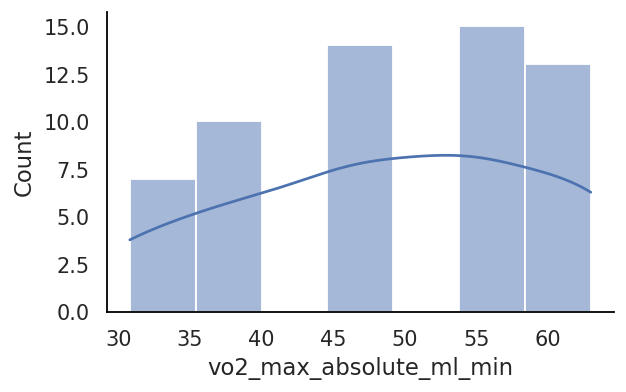

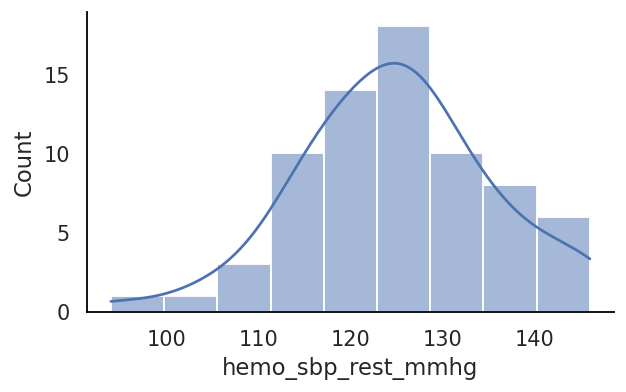

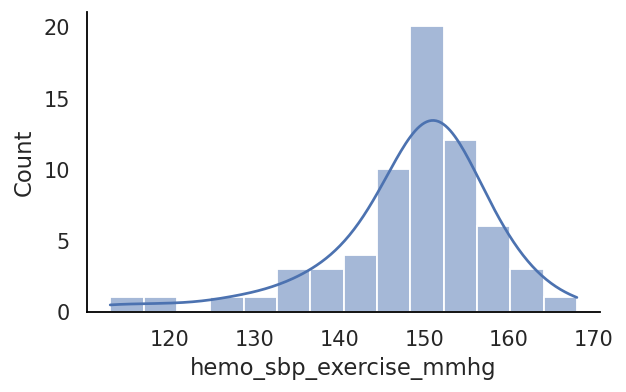

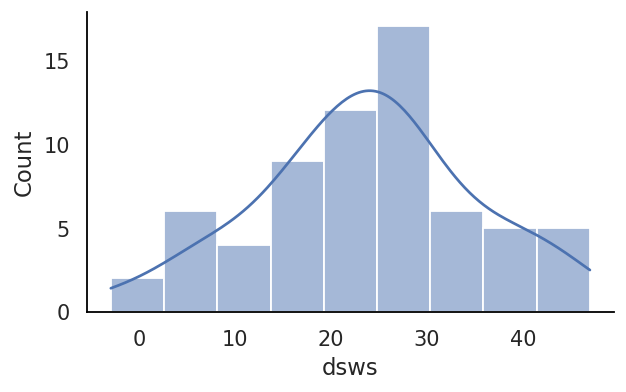

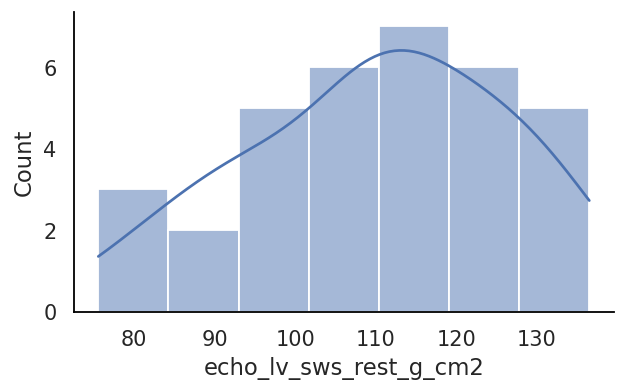

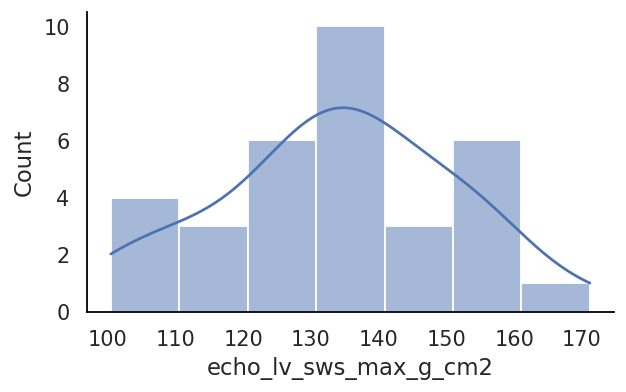

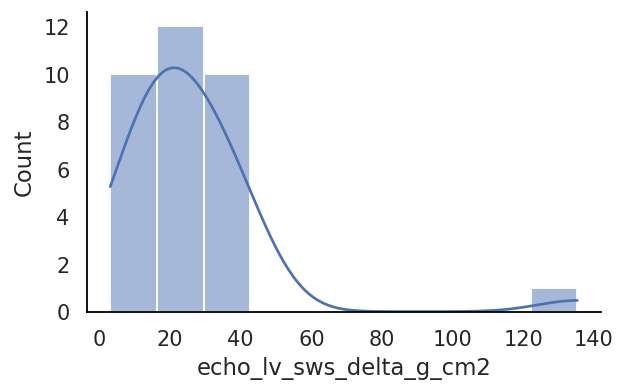

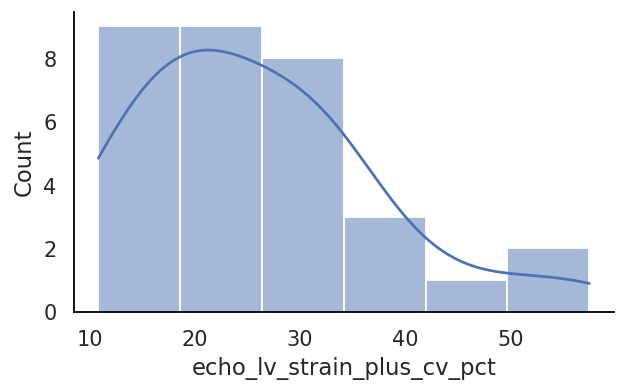

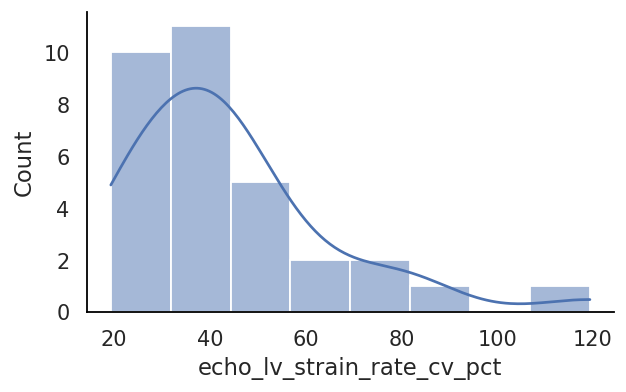

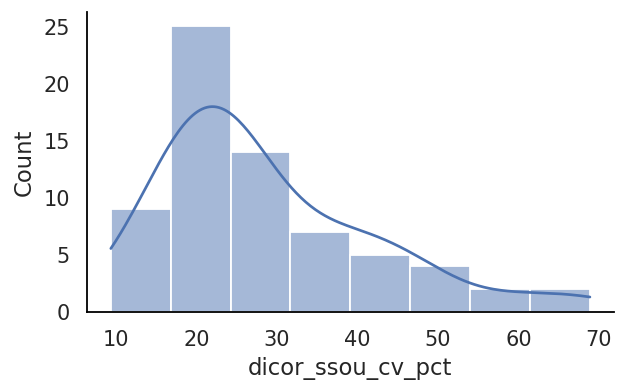

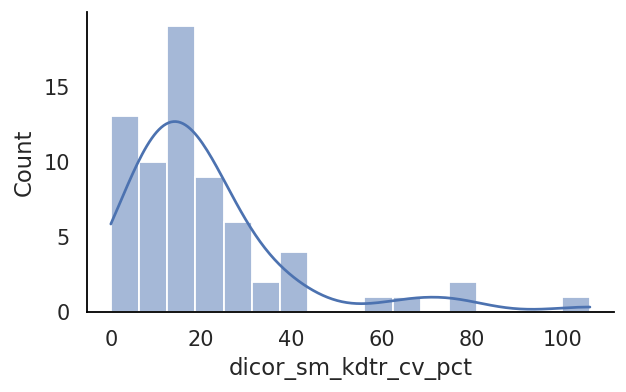

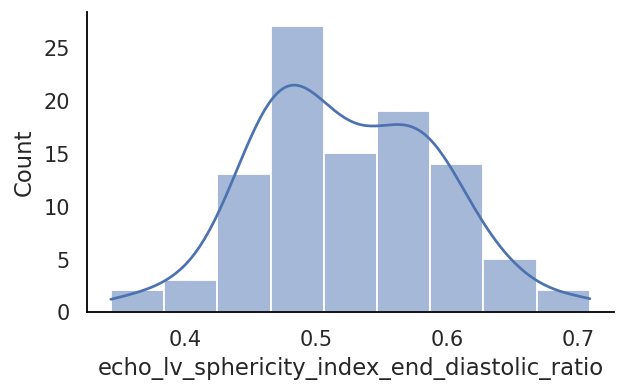

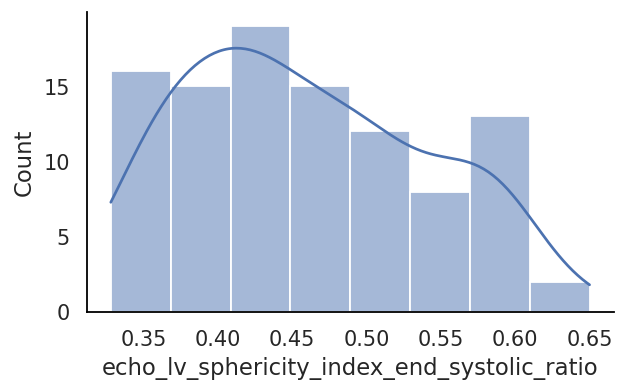

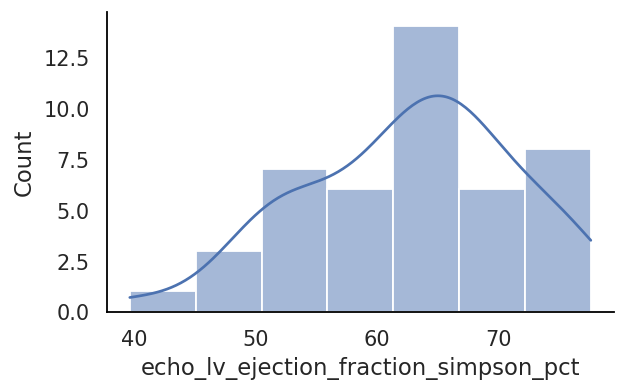

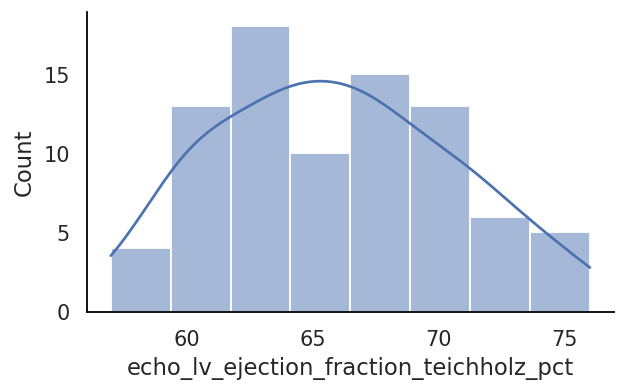

In [12]:
# 12. Plot distributions of key numeric variables
key_numeric_for_dist = [v for v in ([VO2MAX_VAR] if VO2MAX_VAR else []) + pressure_vars + sws_vars + outcome_vars if v in num_vars]

for v in key_numeric_for_dist:
    tmp = analysis_df[[v]].dropna()
    if tmp.shape[0] < 5:
        continue
    fig, ax = plt.subplots(figsize=(5, 3.2))
    sns.histplot(data=tmp, x=v, kde=True, ax=ax)
    ax.set_xlabel(v)
    ax.set_ylabel("Count")
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"dist_{v}.png", bbox_inches="tight")
    plt.show()

## 2. Простые связи: корреляционный слой

Здесь используем **Spearman**, потому что:

- выборка небольшая;
- часть переменных может быть не нормально распределена;
- связи могут быть монотонными, но не строго линейными.

Корреляции — это не доказательство влияния. Это карта направлений, куда есть смысл смотреть глубже.

In [13]:
# 13. Spearman correlation matrix among VO2max, pressure, SWS, outcomes and numeric chord counts
corr_vars = []
for block in [chord_vars, ([VO2MAX_VAR] if VO2MAX_VAR else []), pressure_vars, sws_vars, outcome_vars]:
    for v in block:
        if v in analysis_df.columns and pd.api.types.is_numeric_dtype(analysis_df[v]):
            corr_vars.append(v)

corr_vars = list(dict.fromkeys(corr_vars))
print("Correlation variables:", corr_vars)

corr_rows = []
for i, x in enumerate(corr_vars):
    for y in corr_vars[i+1:]:
        tmp = analysis_df[[x, y]].dropna()
        if tmp.shape[0] < 8:
            continue
        rho, p = stats.spearmanr(tmp[x], tmp[y])
        corr_rows.append({
            "x": x,
            "y": y,
            "n": int(tmp.shape[0]),
            "spearman_rho": float(rho),
            "p_value": float(p),
        })

corr_table = pd.DataFrame(corr_rows)
if not corr_table.empty:
    corr_table["p_fdr"] = multipletests(corr_table["p_value"], method="fdr_bh")[1]
    corr_table["abs_rho"] = corr_table["spearman_rho"].abs()
    corr_table = corr_table.sort_values(["p_fdr", "abs_rho"], ascending=[True, False])

display(corr_table.head(30))
save_table(corr_table, "03_spearman_correlations_fdr.xlsx")

Correlation variables: ['lv_false_tendon_total_count', 'significant_lv_chord_bp_count', 'vo2_max_absolute_ml_min', 'hemo_sbp_rest_mmhg', 'hemo_sbp_exercise_mmhg', 'dsws', 'echo_lv_sws_rest_g_cm2', 'echo_lv_sws_max_g_cm2', 'echo_lv_sws_delta_g_cm2', 'echo_lv_strain_plus_cv_pct', 'echo_lv_strain_rate_cv_pct', 'dicor_ssou_cv_pct', 'dicor_sm_kdtr_cv_pct', 'echo_lv_sphericity_index_end_diastolic_ratio', 'echo_lv_sphericity_index_end_systolic_ratio', 'echo_lv_ejection_fraction_simpson_pct', 'echo_lv_ejection_fraction_teichholz_pct']


,x,y,n,spearman_rho,p_value,p_fdr,abs_rho
0,lv_false_tendon_total_count,significant_lv_chord_bp_count,65,0.999456,4.587677e-95,4.771184e-93,0.999456
98,echo_lv_sphericity_index_end_diastolic_ratio,echo_lv_sphericity_index_end_systolic_ratio,100,0.705276,2.581677e-16,1.342472e-14,0.705276
40,hemo_sbp_rest_mmhg,dsws,66,-0.632701,1.202919e-08,4.170119e-07,0.632701
66,echo_lv_sws_rest_g_cm2,echo_lv_sws_max_g_cm2,32,0.751054,7.331702e-07,1.906243e-05,0.751054
49,hemo_sbp_exercise_mmhg,dsws,66,0.473078,6.037691e-05,1.255840e-03,0.473078
14,lv_false_tendon_total_count,echo_lv_ejection_fraction_simpson_pct,42,-0.533557,2.741248e-04,4.751497e-03,0.533557
47,hemo_sbp_rest_mmhg,echo_lv_sphericity_index_end_systolic_ratio,68,-0.379944,1.394603e-03,2.071982e-02,0.379944
84,echo_lv_strain_plus_cv_pct,echo_lv_strain_rate_cv_pct,32,0.505865,3.139671e-03,4.081573e-02,0.505865
78,echo_lv_sws_max_g_cm2,echo_lv_ejection_fraction_teichholz_pct,30,-0.472406,8.389408e-03,9.694427e-02,0.472406
83,echo_lv_sws_delta_g_cm2,echo_lv_ejection_fraction_teichholz_pct,30,-0.452244,1.210347e-02,1.144328e-01,0.452244


Saved: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\chords_vo2max_sws\tables\03_spearman_correlations_fdr.xlsx


WindowsPath('C:/Users/Ars/projects/university/lab_urfu_2026/false-lv-chords/outputs/chords_vo2max_sws/tables/03_spearman_correlations_fdr.xlsx')

,x,y,n,spearman_rho,p_value,p_fdr,abs_rho
40,hemo_sbp_rest_mmhg,dsws,66,-0.632701,1.202919e-08,4.170119e-07,0.632701
66,echo_lv_sws_rest_g_cm2,echo_lv_sws_max_g_cm2,32,0.751054,7.331702e-07,1.906243e-05,0.751054
49,hemo_sbp_exercise_mmhg,dsws,66,0.473078,6.037691e-05,1.255840e-03,0.473078
47,hemo_sbp_rest_mmhg,echo_lv_sphericity_index_end_systolic_ratio,68,-0.379944,1.394603e-03,2.071982e-02,0.379944
78,echo_lv_sws_max_g_cm2,echo_lv_ejection_fraction_teichholz_pct,30,-0.472406,8.389408e-03,9.694427e-02,0.472406
83,echo_lv_sws_delta_g_cm2,echo_lv_ejection_fraction_teichholz_pct,30,-0.452244,1.210347e-02,1.144328e-01,0.452244
73,echo_lv_sws_max_g_cm2,echo_lv_sws_delta_g_cm2,33,0.435698,1.126259e-02,1.144328e-01,0.435698
39,hemo_sbp_rest_mmhg,hemo_sbp_exercise_mmhg,66,0.276528,2.460018e-02,2.103353e-01,0.276528
60,dsws,echo_lv_sws_delta_g_cm2,28,0.368249,5.383993e-02,3.127592e-01,0.368249
79,echo_lv_sws_delta_g_cm2,dicor_ssou_cv_pct,29,0.366502,5.052262e-02,3.127592e-01,0.366502


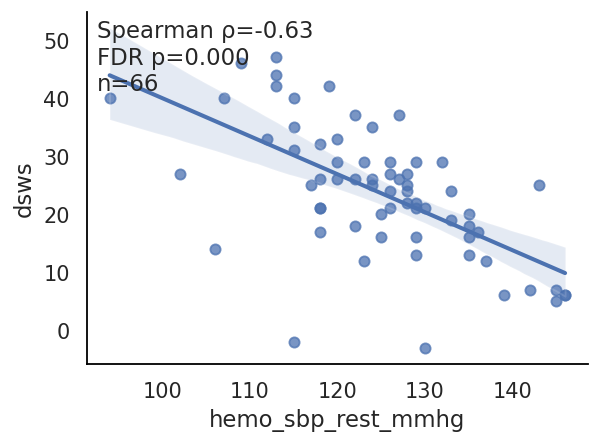

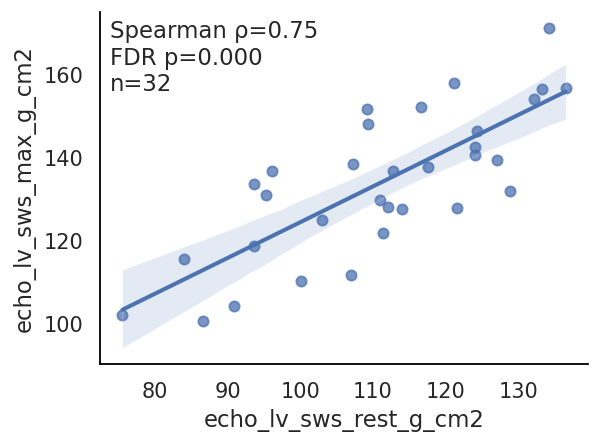

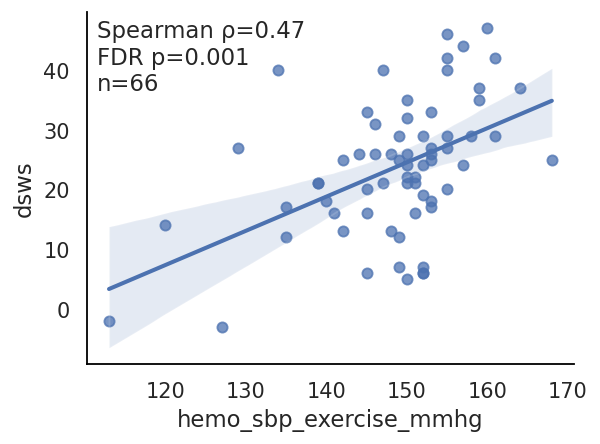

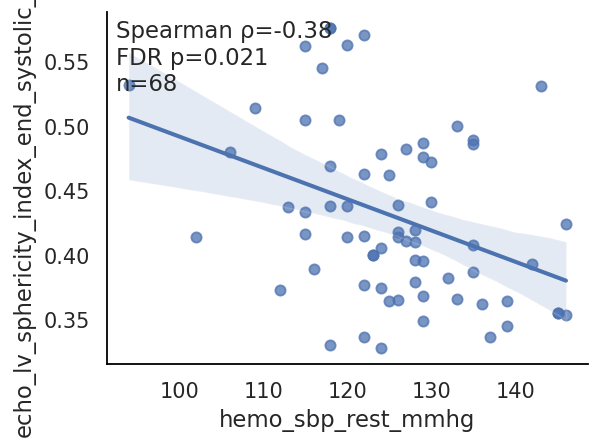

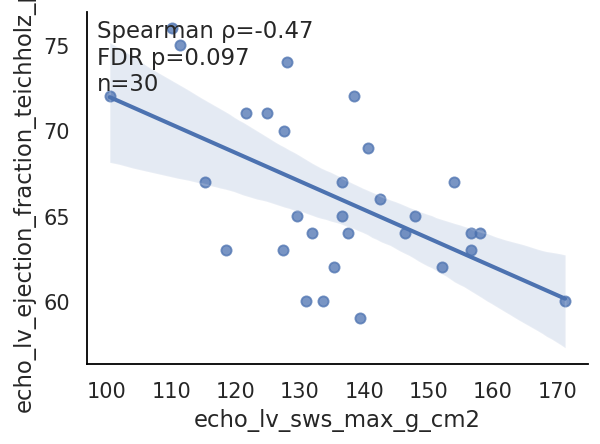

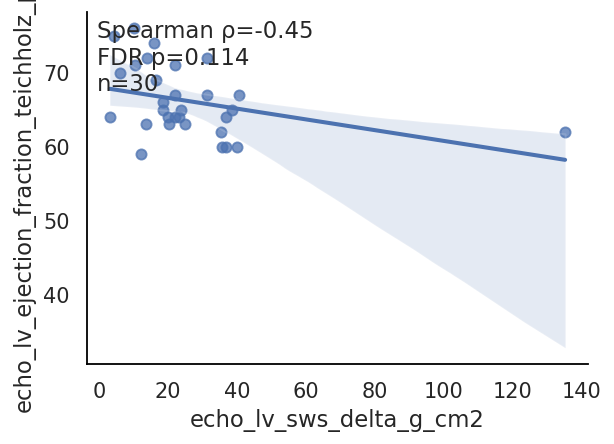

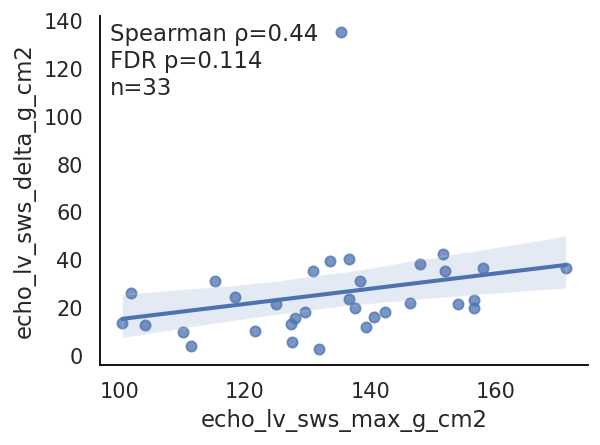

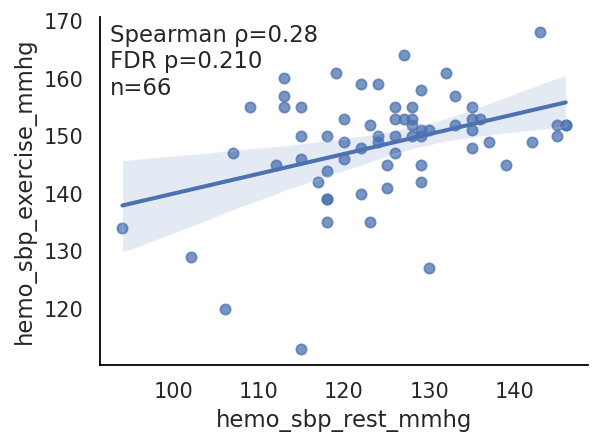

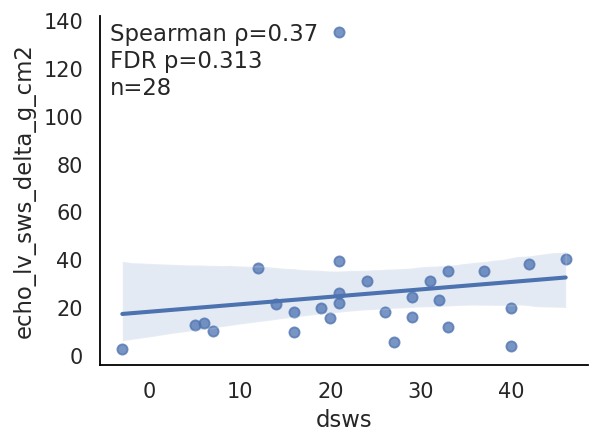

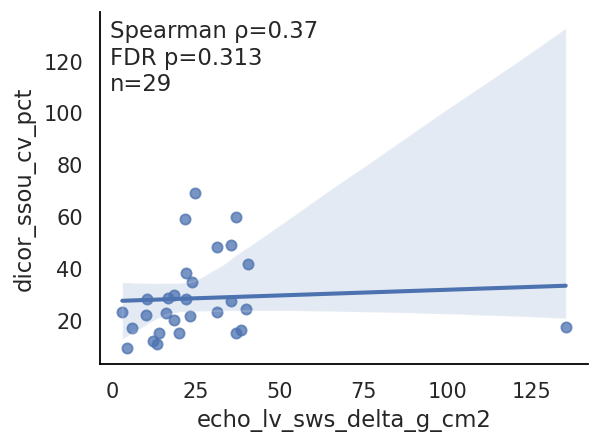

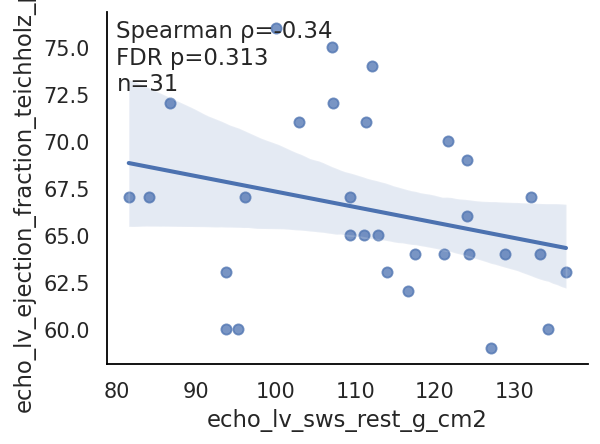

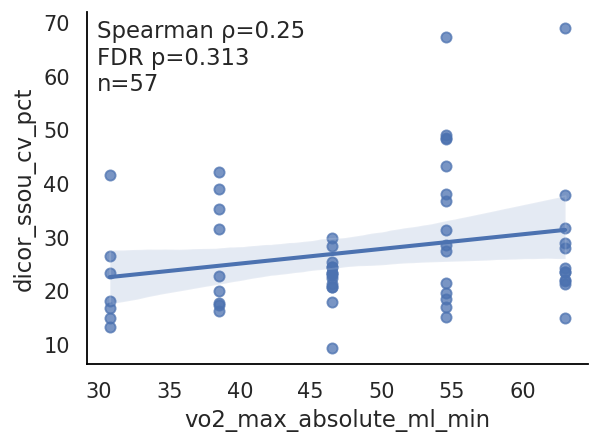

In [14]:
# 14. Scatter plots for top correlations involving VO2max / SWS / dsws
if not corr_table.empty:
    target_keywords = ["vo2", "sws", "dsws", "sbp"]
    top_pairs = corr_table[
        corr_table["x"].str.lower().str.contains("|".join(target_keywords), regex=True) |
        corr_table["y"].str.lower().str.contains("|".join(target_keywords), regex=True)
    ].head(12)

    display(top_pairs)

    for _, row in top_pairs.iterrows():
        x, y = row["x"], row["y"]
        tmp = analysis_df[[x, y]].dropna()
        if tmp.shape[0] < 8:
            continue
        fig, ax = plt.subplots(figsize=(4.8, 3.6))
        sns.regplot(data=tmp, x=x, y=y, scatter_kws={"s": 32, "alpha": 0.75}, ci=95, ax=ax)
        ax.set_xlabel(x)
        ax.set_ylabel(y)
        ax.text(0.02, 0.98, f"Spearman ρ={row['spearman_rho']:.2f}\nFDR p={row['p_fdr']:.3f}\nn={int(row['n'])}",
                transform=ax.transAxes, va="top", ha="left")
        fig.tight_layout()
        fig.savefig(FIG_DIR / f"scatter_{x}_vs_{y}.png", bbox_inches="tight")
        plt.show()

## 3. Группы хорд: сравнение VO₂max, САД, SWS и механики

Здесь проверяем, отличаются ли физиологические и механические показатели между группами хорд.

Главные группировки:

- `Chord_Orientation` / `chord_orientation`;
- `Chord_Spread_Class` / `chord_spread_class`;
- `Chord_Topology_Class` / `chord_topology_class`;
- `chord_type_complexity_class`, если есть.

Смотрим не только `p-value`, но и:

- размер эффекта;
- направление эффекта;
- `n` в каждой группе;
- устойчивость на bootstrap.

In [15]:
# 15. Group comparison helpers

def hedges_g(x, y):
    x = pd.Series(x).dropna().astype(float)
    y = pd.Series(y).dropna().astype(float)
    nx, ny = len(x), len(y)
    if nx < 2 or ny < 2:
        return np.nan
    sx, sy = x.var(ddof=1), y.var(ddof=1)
    pooled = np.sqrt(((nx - 1) * sx + (ny - 1) * sy) / (nx + ny - 2))
    if pooled == 0 or np.isnan(pooled):
        return np.nan
    d = (x.mean() - y.mean()) / pooled
    correction = 1 - (3 / (4 * (nx + ny) - 9))
    return d * correction


def bootstrap_mean_diff(x, y, n_boot=3000, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    x = np.array(pd.Series(x).dropna().astype(float))
    y = np.array(pd.Series(y).dropna().astype(float))
    if len(x) < 3 or len(y) < 3:
        return np.nan, np.nan, np.nan
    diffs = []
    for _ in range(n_boot):
        xb = rng.choice(x, size=len(x), replace=True)
        yb = rng.choice(y, size=len(y), replace=True)
        diffs.append(np.mean(xb) - np.mean(yb))
    return float(np.mean(diffs)), float(np.percentile(diffs, 2.5)), float(np.percentile(diffs, 97.5))


def compare_groups(df, group_var, outcome_var, min_group_n=5):
    tmp = df[[group_var, outcome_var]].dropna().copy()
    if tmp.empty:
        return None
    # Drop very small groups
    counts = tmp[group_var].value_counts()
    keep_groups = counts[counts >= min_group_n].index.tolist()
    tmp = tmp[tmp[group_var].isin(keep_groups)]
    groups = sorted(tmp[group_var].dropna().unique().tolist(), key=str)
    if len(groups) < 2:
        return None

    values = [tmp.loc[tmp[group_var] == g, outcome_var].astype(float) for g in groups]
    row = {
        "group_var": group_var,
        "outcome": outcome_var,
        "n_total": int(tmp.shape[0]),
        "groups": " | ".join(map(str, groups)),
        "group_n": " | ".join([f"{g}:{len(v)}" for g, v in zip(groups, values)]),
        "group_mean": " | ".join([f"{g}:{np.mean(v):.3f}" for g, v in zip(groups, values)]),
        "group_median": " | ".join([f"{g}:{np.median(v):.3f}" for g, v in zip(groups, values)]),
    }

    if len(groups) == 2:
        stat, p = stats.mannwhitneyu(values[0], values[1], alternative="two-sided")
        row.update({
            "test": "Mann-Whitney U",
            "statistic": float(stat),
            "p_value": float(p),
            "hedges_g_group1_minus_group2": float(hedges_g(values[0], values[1])),
        })
        boot_mean, boot_low, boot_high = bootstrap_mean_diff(values[0], values[1])
        row.update({
            "boot_mean_diff_group1_minus_group2": boot_mean,
            "boot_ci95_low": boot_low,
            "boot_ci95_high": boot_high,
        })
    else:
        stat, p = stats.kruskal(*values)
        n = sum(len(v) for v in values)
        k = len(values)
        eta2_h = (stat - k + 1) / (n - k) if n > k else np.nan
        row.update({
            "test": "Kruskal-Wallis",
            "statistic": float(stat),
            "p_value": float(p),
            "epsilon_or_eta2_h": float(eta2_h),
        })

    return row

In [16]:
# 16. Run group comparisons
categorical_chord_vars = [
    v for v in chord_vars
    if v in analysis_df.columns and (analysis_df[v].dtype == "object" or analysis_df[v].nunique(dropna=True) <= 8)
]

# Не считаем числовой count как категорию, если там много уровней
categorical_chord_vars = [v for v in categorical_chord_vars if not (pd.api.types.is_numeric_dtype(analysis_df[v]) and analysis_df[v].nunique(dropna=True) > 4)]

group_outcomes = [v for v in ([VO2MAX_VAR] if VO2MAX_VAR else []) + pressure_vars + sws_vars + outcome_vars if v in analysis_df.columns and pd.api.types.is_numeric_dtype(analysis_df[v])]

comparison_rows = []
for g in categorical_chord_vars:
    for y in group_outcomes:
        res = compare_groups(analysis_df, g, y, min_group_n=4)
        if res is not None:
            comparison_rows.append(res)

comparison_table = pd.DataFrame(comparison_rows)
if not comparison_table.empty:
    comparison_table["p_fdr"] = multipletests(comparison_table["p_value"], method="fdr_bh")[1]
    comparison_table = comparison_table.sort_values(["p_fdr", "p_value"])

display(comparison_table.head(40))
save_table(comparison_table, "04_chord_group_comparisons.xlsx")

""


Saved: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\chords_vo2max_sws\tables\04_chord_group_comparisons.xlsx


WindowsPath('C:/Users/Ars/projects/university/lab_urfu_2026/false-lv-chords/outputs/chords_vo2max_sws/tables/04_chord_group_comparisons.xlsx')

In [17]:
# 17. Boxplot + stripplot for the most interesting group comparisons
if not comparison_table.empty:
    plot_candidates = comparison_table.head(12)
    display(plot_candidates[["group_var", "outcome", "test", "p_value", "p_fdr", "group_n", "group_mean"]])

    for _, row in plot_candidates.iterrows():
        g, y = row["group_var"], row["outcome"]
        tmp = analysis_df[[g, y]].dropna().copy()
        counts = tmp[g].value_counts()
        tmp = tmp[tmp[g].isin(counts[counts >= 4].index)]
        if tmp[g].nunique() < 2:
            continue
        fig, ax = plt.subplots(figsize=(5.6, 3.8))
        sns.boxplot(data=tmp, x=g, y=y, showfliers=False, ax=ax)
        sns.stripplot(data=tmp, x=g, y=y, jitter=True, size=4, alpha=0.75, ax=ax)
        ax.set_xlabel(g)
        ax.set_ylabel(y)
        ax.tick_params(axis="x", rotation=20)
        ax.text(0.02, 0.98, f"{row['test']}\np={row['p_value']:.3f}, FDR={row['p_fdr']:.3f}",
                transform=ax.transAxes, va="top", ha="left")
        fig.tight_layout()
        fig.savefig(FIG_DIR / f"box_{g}_vs_{y}.png", bbox_inches="tight")
        plt.show()

## 4. Иерархические регрессии

Здесь логика такая:

```text
M0: outcome ~ age + sex + BSA/BMI
M1: M0 + VO2max
M2: M1 + hemo_sbp_rest_mmhg + hemo_sbp_exercise_mmhg + dsws
M3: M2 + echo_lv_sws_rest_g_cm2 + echo_lv_sws_max_g_cm2 + echo_lv_sws_delta_g_cm2
M4: M3 + chord phenotype
M5: M4 + interaction terms
```

Интерпретация:

- если при добавлении `VO2max` растёт `R²`, значит функциональная работоспособность объясняет часть вариабельности механики;
- если после добавления SWS ослабевает эффект хорд, SWS может быть механическим промежуточным слоем;
- если значимо взаимодействие `хорда × SWS` или `хорда × VO2max`, значит эффект хорд может проявляться только при определённой нагрузке/работоспособности.

Важно: это не окончательное causal-доказательство, а mechanistic exploratory modelling.

In [18]:
# 18. Regression helpers

def is_categorical_for_formula(df, v):
    return (
        v in df.columns and
        (df[v].dtype == "object" or str(df[v].dtype).startswith("category"))
    )


def formula_term(df, v):
    if is_categorical_for_formula(df, v):
        return f"C({v})"
    return v


def build_formula(df, outcome, predictors):
    predictors = [p for p in predictors if p in df.columns and p != outcome]
    if not predictors:
        return None
    return f"{outcome} ~ " + " + ".join([formula_term(df, p) for p in predictors])


def fit_robust_ols(df, outcome, predictors, min_n=20):
    vars_needed = [outcome] + [p for p in predictors if p in df.columns]
    tmp = df[vars_needed].dropna().copy()
    if tmp.shape[0] < min_n:
        return None, {"error": f"n<{min_n}", "n": int(tmp.shape[0])}
    # Avoid models too complex for available n
    approx_params = 1 + sum([(tmp[p].nunique() - 1) if is_categorical_for_formula(tmp, p) else 1 for p in predictors if p in tmp.columns])
    if tmp.shape[0] < max(min_n, approx_params * 5):
        return None, {"error": "too_many_parameters_for_n", "n": int(tmp.shape[0]), "approx_params": int(approx_params)}

    formula = build_formula(tmp, outcome, predictors)
    try:
        model = smf.ols(formula, data=tmp).fit(cov_type="HC3")
        info = {
            "formula": formula,
            "n": int(model.nobs),
            "r2": float(model.rsquared),
            "adj_r2": float(model.rsquared_adj),
            "aic": float(model.aic),
            "bic": float(model.bic),
            "f_pvalue": float(model.f_pvalue) if model.f_pvalue is not None else np.nan,
        }
        return model, info
    except Exception as e:
        return None, {"error": str(e), "formula": formula, "n": int(tmp.shape[0])}


def model_coef_table(model, model_name, outcome):
    if model is None:
        return pd.DataFrame()
    ci = model.conf_int()
    out = pd.DataFrame({
        "outcome": outcome,
        "model": model_name,
        "term": model.params.index,
        "coef": model.params.values,
        "std_err": model.bse.values,
        "p_value": model.pvalues.values,
        "ci_low": ci[0].values,
        "ci_high": ci[1].values,
    })
    return out

In [19]:
# 19. Build hierarchical models for each outcome
# Чтобы не перегружать маленькую выборку, берём только доступные переменные.

# Выбираем один-два основных признака хорды для регрессии.
# Приоритет: ориентация/распространение/количество.
preferred_chord_predictors = [
    "Chord_Orientation", "chord_orientation",
    "Chord_Spread_Class", "chord_spread_class",
    "lv_false_tendon_total_count", "significant_lv_chord_bp_count",
]
chord_predictors_for_models = existing(preferred_chord_predictors, analysis_df)

model_blocks = {
    "M0_covariates": covariates,
    "M1_plus_vo2max": covariates + ([VO2MAX_VAR] if VO2MAX_VAR else []),
    "M2_plus_pressure": covariates + ([VO2MAX_VAR] if VO2MAX_VAR else []) + pressure_vars,
    "M3_plus_sws": covariates + ([VO2MAX_VAR] if VO2MAX_VAR else []) + pressure_vars + sws_vars,
    "M4_plus_chords": covariates + ([VO2MAX_VAR] if VO2MAX_VAR else []) + pressure_vars + sws_vars + chord_predictors_for_models,
}

model_summaries = []
coef_tables = []
models = {}

for outcome in outcome_vars:
    if outcome not in analysis_df.columns or not pd.api.types.is_numeric_dtype(analysis_df[outcome]):
        continue
    for model_name, predictors in model_blocks.items():
        predictors = [p for p in predictors if p in analysis_df.columns and p != outcome]
        model, info = fit_robust_ols(analysis_df, outcome, predictors, min_n=20)
        info.update({"outcome": outcome, "model": model_name, "predictors": ", ".join(predictors)})
        model_summaries.append(info)
        if model is not None:
            models[(outcome, model_name)] = model
            coef_tables.append(model_coef_table(model, model_name, outcome))

model_summary_table = pd.DataFrame(model_summaries)
coef_table = pd.concat(coef_tables, ignore_index=True) if coef_tables else pd.DataFrame()

# ΔR² относительно предыдущей модели внутри каждого outcome
if not model_summary_table.empty and "r2" in model_summary_table.columns:
    model_order = list(model_blocks.keys())
    model_summary_table["model_order"] = model_summary_table["model"].map({m: i for i, m in enumerate(model_order)})
    model_summary_table = model_summary_table.sort_values(["outcome", "model_order"])
    model_summary_table["delta_r2"] = model_summary_table.groupby("outcome")["r2"].diff()

print("Model summary:")
display(model_summary_table)
print("Coefficients:")
display(coef_table.head(40))

save_table(model_summary_table, "05_hierarchical_model_summary.xlsx")
save_table(coef_table, "06_hierarchical_model_coefficients.xlsx")

Model summary:


,error,n,outcome,model,predictors,formula,r2,adj_r2,aic,bic,f_pvalue,approx_params,model_order,delta_r2
15,NaN,66,dicor_sm_kdtr_cv_pct,M0_covariates,sex,dicor_sm_kdtr_cv_pct ~ sex,0.000221,-0.015400,580.147864,584.527173,0.908369,NaN,0,NaN
16,NaN,57,dicor_sm_kdtr_cv_pct,M1_plus_vo2max,"sex, vo2_max_absolute_ml_min",dicor_sm_kdtr_cv_pct ~ sex + vo2_max_absolute_...,0.006783,-0.030003,495.672592,501.801746,0.792119,NaN,1,0.006562
17,NaN,57,dicor_sm_kdtr_cv_pct,M2_plus_pressure,"sex, vo2_max_absolute_ml_min, hemo_sbp_rest_mm...",dicor_sm_kdtr_cv_pct ~ sex + vo2_max_absolute_...,0.073151,0.001855,495.730547,505.945803,0.268330,NaN,2,0.066368
18,too_many_parameters_for_n,23,dicor_sm_kdtr_cv_pct,M3_plus_sws,"sex, vo2_max_absolute_ml_min, hemo_sbp_rest_mm...",NaN,NaN,NaN,NaN,NaN,NaN,9.0,3,NaN
19,too_many_parameters_for_n,22,dicor_sm_kdtr_cv_pct,M4_plus_chords,"sex, vo2_max_absolute_ml_min, hemo_sbp_rest_mm...",NaN,NaN,NaN,NaN,NaN,NaN,11.0,4,NaN
10,NaN,66,dicor_ssou_cv_pct,M0_covariates,sex,dicor_ssou_cv_pct ~ sex,0.137175,0.123694,521.574469,525.953778,0.000948,NaN,0,NaN
11,NaN,57,dicor_ssou_cv_pct,M1_plus_vo2max,"sex, vo2_max_absolute_ml_min",dicor_ssou_cv_pct ~ sex + vo2_max_absolute_ml_min,0.156336,0.125089,441.538101,447.667255,0.017143,NaN,1,0.019161
12,NaN,57,dicor_ssou_cv_pct,M2_plus_pressure,"sex, vo2_max_absolute_ml_min, hemo_sbp_rest_mm...",dicor_ssou_cv_pct ~ sex + vo2_max_absolute_ml_...,0.172615,0.108970,444.427519,454.642775,0.079281,NaN,2,0.016279
13,too_many_parameters_for_n,23,dicor_ssou_cv_pct,M3_plus_sws,"sex, vo2_max_absolute_ml_min, hemo_sbp_rest_mm...",NaN,NaN,NaN,NaN,NaN,NaN,9.0,3,NaN
14,too_many_parameters_for_n,22,dicor_ssou_cv_pct,M4_plus_chords,"sex, vo2_max_absolute_ml_min, hemo_sbp_rest_mm...",NaN,NaN,NaN,NaN,NaN,NaN,11.0,4,NaN


Coefficients:


,outcome,model,term,coef,std_err,p_value,ci_low,ci_high
0,dicor_ssou_cv_pct,M0_covariates,Intercept,42.733686,5.156539,1.158666e-16,32.627056,52.840316
1,dicor_ssou_cv_pct,M0_covariates,sex,-9.848938,2.841513,5.280884e-04,-15.418202,-4.279674
2,dicor_ssou_cv_pct,M1_plus_vo2max,Intercept,28.367859,7.224276,8.610463e-05,14.208539,42.527178
3,dicor_ssou_cv_pct,M1_plus_vo2max,sex,-7.739899,2.761743,5.070168e-03,-13.152815,-2.326983
4,dicor_ssou_cv_pct,M1_plus_vo2max,vo2_max_absolute_ml_min,0.211873,0.134272,1.145791e-01,-0.051295,0.475041
5,dicor_ssou_cv_pct,M2_plus_pressure,Intercept,20.331559,32.976683,5.375359e-01,-44.301552,84.964671
6,dicor_ssou_cv_pct,M2_plus_pressure,sex,-6.940056,2.796451,1.307438e-02,-12.421000,-1.459112
7,dicor_ssou_cv_pct,M2_plus_pressure,vo2_max_absolute_ml_min,0.220769,0.134372,1.003896e-01,-0.042595,0.484133
8,dicor_ssou_cv_pct,M2_plus_pressure,hemo_sbp_rest_mmhg,-0.038535,0.148692,7.955135e-01,-0.329965,0.252896
9,dicor_ssou_cv_pct,M2_plus_pressure,hemo_sbp_exercise_mmhg,0.060208,0.128051,6.382209e-01,-0.190767,0.311182


Saved: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\chords_vo2max_sws\tables\05_hierarchical_model_summary.xlsx
Saved: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\chords_vo2max_sws\tables\06_hierarchical_model_coefficients.xlsx


WindowsPath('C:/Users/Ars/projects/university/lab_urfu_2026/false-lv-chords/outputs/chords_vo2max_sws/tables/06_hierarchical_model_coefficients.xlsx')

In [20]:
# 20. Show best models by adjusted R² and n
if not model_summary_table.empty:
    cols = [c for c in ["outcome", "model", "n", "r2", "adj_r2", "delta_r2", "aic", "bic", "error", "predictors"] if c in model_summary_table.columns]
    display(
        model_summary_table[cols]
        .sort_values(["outcome", "adj_r2"], ascending=[True, False])
        .groupby("outcome")
        .head(3)
    )

,outcome,model,n,r2,adj_r2,delta_r2,aic,bic,error,predictors
17,dicor_sm_kdtr_cv_pct,M2_plus_pressure,57,0.073151,0.001855,0.066368,495.730547,505.945803,NaN,"sex, vo2_max_absolute_ml_min, hemo_sbp_rest_mm..."
15,dicor_sm_kdtr_cv_pct,M0_covariates,66,0.000221,-0.015400,NaN,580.147864,584.527173,NaN,sex
16,dicor_sm_kdtr_cv_pct,M1_plus_vo2max,57,0.006783,-0.030003,0.006562,495.672592,501.801746,NaN,"sex, vo2_max_absolute_ml_min"
11,dicor_ssou_cv_pct,M1_plus_vo2max,57,0.156336,0.125089,0.019161,441.538101,447.667255,NaN,"sex, vo2_max_absolute_ml_min"
10,dicor_ssou_cv_pct,M0_covariates,66,0.137175,0.123694,NaN,521.574469,525.953778,NaN,sex
12,dicor_ssou_cv_pct,M2_plus_pressure,57,0.172615,0.108970,0.016279,444.427519,454.642775,NaN,"sex, vo2_max_absolute_ml_min, hemo_sbp_rest_mm..."
30,echo_lv_ejection_fraction_simpson_pct,M0_covariates,0,NaN,NaN,NaN,NaN,NaN,n<20,sex
31,echo_lv_ejection_fraction_simpson_pct,M1_plus_vo2max,0,NaN,NaN,NaN,NaN,NaN,n<20,"sex, vo2_max_absolute_ml_min"
32,echo_lv_ejection_fraction_simpson_pct,M2_plus_pressure,0,NaN,NaN,NaN,NaN,NaN,n<20,"sex, vo2_max_absolute_ml_min, hemo_sbp_rest_mm..."
36,echo_lv_ejection_fraction_teichholz_pct,M1_plus_vo2max,57,0.131745,0.099588,0.041967,335.392994,341.522148,NaN,"sex, vo2_max_absolute_ml_min"


## 5. Модерация: хорда × VO₂max / хорда × SWS

Этот слой нужен, если простая модель говорит: «в среднем эффекта нет», но физиологически возможно, что эффект хорд проявляется только при большей нагрузке или при другом уровне функциональной подготовленности.

Примеры вопросов:

```text
Связь SWS_delta с strain_rate_CV отличается у Transverse-Involved и Oblique-Only?
Связь VO2max с механической дисперсией отличается по ориентации хорд?
```

Если interaction есть, интерпретируем не как «одна группа хуже», а как «механический ответ на нагрузку отличается между фенотипами хорд».

In [21]:
# 21. Interaction models: chord orientation/spread × VO2max/SWS_delta
interaction_chord_candidates = existing([
    "Chord_Orientation", "chord_orientation",
    "Chord_Spread_Class", "chord_spread_class",
], analysis_df)

interaction_continuous_candidates = [v for v in [VO2MAX_VAR, "echo_lv_sws_delta_g_cm2", "dsws"] if v and v in analysis_df.columns]

interaction_rows = []
interaction_coef_tables = []

for outcome in outcome_vars:
    if outcome not in analysis_df.columns or not pd.api.types.is_numeric_dtype(analysis_df[outcome]):
        continue
    for g in interaction_chord_candidates:
        for x in interaction_continuous_candidates:
            base_predictors = [p for p in covariates if p in analysis_df.columns]
            vars_needed = [outcome, g, x] + base_predictors
            tmp = analysis_df[vars_needed].dropna().copy()
            if tmp.shape[0] < 25 or tmp[g].nunique() < 2:
                continue
            # Пропускаем слишком маленькие группы
            counts = tmp[g].value_counts()
            tmp = tmp[tmp[g].isin(counts[counts >= 5].index)]
            if tmp.shape[0] < 25 or tmp[g].nunique() < 2:
                continue
            formula = f"{outcome} ~ " + " + ".join([formula_term(tmp, p) for p in base_predictors])
            if base_predictors:
                formula += " + "
            formula += f"C({g}) * {x}"
            try:
                model = smf.ols(formula, data=tmp).fit(cov_type="HC3")
                interaction_terms = [term for term in model.params.index if ":" in term]
                min_interaction_p = float(model.pvalues[interaction_terms].min()) if interaction_terms else np.nan
                interaction_rows.append({
                    "outcome": outcome,
                    "group_var": g,
                    "continuous_var": x,
                    "n": int(model.nobs),
                    "r2": float(model.rsquared),
                    "adj_r2": float(model.rsquared_adj),
                    "min_interaction_p": min_interaction_p,
                    "formula": formula,
                })
                tab = model_coef_table(model, f"interaction_{g}_x_{x}", outcome)
                interaction_coef_tables.append(tab)
            except Exception as e:
                interaction_rows.append({
                    "outcome": outcome,
                    "group_var": g,
                    "continuous_var": x,
                    "error": str(e),
                    "formula": formula,
                })

interaction_summary = pd.DataFrame(interaction_rows)
if not interaction_summary.empty and "min_interaction_p" in interaction_summary.columns:
    valid_p = interaction_summary["min_interaction_p"].notna()
    interaction_summary.loc[valid_p, "interaction_p_fdr"] = multipletests(interaction_summary.loc[valid_p, "min_interaction_p"], method="fdr_bh")[1]
    interaction_summary = interaction_summary.sort_values(["interaction_p_fdr", "min_interaction_p"], na_position="last")

interaction_coefs = pd.concat(interaction_coef_tables, ignore_index=True) if interaction_coef_tables else pd.DataFrame()

display(interaction_summary.head(30))
save_table(interaction_summary, "07_interaction_model_summary.xlsx")
save_table(interaction_coefs, "08_interaction_model_coefficients.xlsx")

""


Saved: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\chords_vo2max_sws\tables\07_interaction_model_summary.xlsx
Saved: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\chords_vo2max_sws\tables\08_interaction_model_coefficients.xlsx


WindowsPath('C:/Users/Ars/projects/university/lab_urfu_2026/false-lv-chords/outputs/chords_vo2max_sws/tables/08_interaction_model_coefficients.xlsx')

## 6. Bootstrap stability for selected effects

Финальная защита от случайных находок:

- знак эффекта должен быть стабильным;
- доверительный интервал не должен быть безумно широким;
- результат не должен зависеть от 1–2 наблюдений.

На этом этапе выбираем 2–5 наиболее интересных связей из предыдущих таблиц и проверяем отдельно.

In [22]:
# 22. Bootstrap slope stability for selected numeric association
# Заполни selected_x / selected_y после просмотра корреляций и моделей.

selected_x = None  # например: "echo_lv_sws_delta_g_cm2"
selected_y = None  # например: "echo_lv_strain_rate_cv_pct"


def bootstrap_spearman(df, x, y, n_boot=5000, seed=RANDOM_STATE):
    tmp = df[[x, y]].dropna().copy()
    if tmp.shape[0] < 10:
        raise ValueError("Too few observations for bootstrap")
    rng = np.random.default_rng(seed)
    vals = []
    for _ in range(n_boot):
        idx = rng.choice(tmp.index, size=len(tmp), replace=True)
        boot = tmp.loc[idx]
        rho, _ = stats.spearmanr(boot[x], boot[y])
        vals.append(rho)
    vals = np.array(vals)
    return pd.Series({
        "x": x,
        "y": y,
        "n": tmp.shape[0],
        "rho_mean_boot": np.nanmean(vals),
        "rho_ci95_low": np.nanpercentile(vals, 2.5),
        "rho_ci95_high": np.nanpercentile(vals, 97.5),
        "sign_stability_pct": max(np.mean(vals > 0), np.mean(vals < 0)) * 100,
    })

if selected_x and selected_y:
    boot_res = bootstrap_spearman(analysis_df, selected_x, selected_y)
    display(boot_res.to_frame().T)

In [23]:
# 23. Save run manifest
run_manifest.update({
    "n_rows": int(df_work.shape[0]),
    "n_columns": int(df_work.shape[1]),
    "variables_used": analysis_vars,
    "vo2max_variable_detected": VO2MAX_VAR,
    "outputs_dir": str(OUTPUT_DIR),
})

manifest_path = DIAG_DIR / "run_manifest.json"
with open(manifest_path, "w", encoding="utf-8") as f:
    json.dump(run_manifest, f, ensure_ascii=False, indent=2)

print(f"Saved manifest: {manifest_path}")
run_manifest

Saved manifest: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\chords_vo2max_sws\diagnostics\run_manifest.json


{'dataset_version': 'final_analysis_dataset_ver2_plus_hemo_sws',
 'dataset_file': 'C:\\Users\\Ars\\projects\\university\\lab_urfu_2026\\false-lv-chords\\data\\final_analysis_dataset_ver2.xlsx',
 'notebook': '04_chords_vo2max_sws_hierarchy.ipynb',
 'random_seed': 42,
 'analysis_goal': 'Relationships among false LV chord phenotype, VO2max, SBP response, LV wall stress, and myocardial mechanics',
 'n_rows': 153,
 'n_columns': 222,
 'variables_used': ['sex',
  'lv_false_tendon_total_count',
  'significant_lv_chord_bp_count',
  'vo2_max_absolute_ml_min',
  'hemo_sbp_rest_mmhg',
  'hemo_sbp_exercise_mmhg',
  'dsws',
  'echo_lv_sws_rest_g_cm2',
  'echo_lv_sws_max_g_cm2',
  'echo_lv_sws_delta_g_cm2',
  'echo_lv_strain_plus_cv_pct',
  'echo_lv_strain_rate_cv_pct',
  'dicor_ssou_cv_pct',
  'dicor_sm_kdtr_cv_pct',
  'echo_lv_sphericity_index_end_diastolic_ratio',
  'echo_lv_sphericity_index_end_systolic_ratio',
  'echo_lv_ejection_fraction_simpson_pct',
  'echo_lv_ejection_fraction_teichholz_pct'

# Как читать результаты этого ноутбука

## Сильный результат

Результат можно считать сильным, если одновременно выполняется несколько условий:

1. связь видна на графике;
2. направление физиологически понятно;
3. размер эффекта не маленький;
4. эффект не исчезает после базовых ковариат;
5. bootstrap показывает устойчивый знак;
6. результат не держится на одном выбросе.

## Слабый, но интересный результат

Если `p > 0.05`, но:

- эффект средний по величине;
- направление совпадает с гипотезой;
- группа маленькая;
- график показывает тренд;

то это не «мусор», а **exploratory signal** для следующей выборки.

## Что будет особенно интересно

1. `Chord_Orientation × echo_lv_sws_delta_g_cm2` → механика ЛЖ.  
2. `Chord_Orientation × VO2max` → strain / DICOR dispersion.  
3. `Chord_Spread_Class` → `dsws` / `echo_lv_sws_delta_g_cm2`.  
4. `VO2max` → `echo_lv_sws_delta_g_cm2` → механическая дисперсия.  
5. Расхождение между `dsws` и `echo_lv_sws_delta_g_cm2`: давление выросло одинаково, но wall stress разный из-за геометрии ЛЖ.